In [1]:
import json
import os
from scipy import stats
from statsmodels.stats.multitest import multipletests
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt



from src.visualization import (
    aggregate_empirical_results, 
    plot_histograms, 
    topic_area_per_project, 
    visualize_policy_population, 
    animate_knowledge_space,
    plot_all_archetypes_distribution,
    save_plot,
    calculate_overall_mean_return,
    plot_mean_reward_trajectories_corrected,
    plot_archetype_vs_controlled_agent,
    plot_archetype_vs_controlled_agent_from_summary,
    plot_archetype_vs_controlled_agent_subplots
)
from src.visualization_utils import get_path_for_strat


In [2]:
ppo_trajectory =  "../results/ppo_agent_exp1/trajectories_ppo.parquet"
appo_trajectory = "../results/appo_agent_exp1/trajectories_appo.parquet"
random_trajectory = "../results/random_agent_exp1/trajectories_random.parquet"

ppo_summary =  "../results/ppo_agent_exp1/summary_by_archetype_ppo.parquet"
appo_summary = "../results/appo_agent_exp1/summary_by_archetype_appo.parquet"
random_summary = "../results/random_agent_exp1/trajectories_random.parquet"

ppo_trajectory_df = pd.read_parquet(ppo_trajectory)
appo_trajectory_df = pd.read_parquet(appo_trajectory)
random_trajectory_df = pd.read_parquet(random_trajectory)

ppo_summary_df =  pd.read_parquet(ppo_summary)
appo_summary_df = pd.read_parquet(appo_summary)
random_summary_df = pd.read_parquet(random_summary)

In [3]:
def add_eval_seed_columns(df, is_rl=True):
    df = df.copy()

    if is_rl:
        # Example: 50103 -> eval_seed=501, model_id=3
        df["eval_seed"] = df["seed"] // 100
        df["model_id"] = df["seed"] % 100
    else:
        # Random has no model dimension
        df["eval_seed"] = df["seed"]
        df["model_id"] = 0

    return df

In [4]:
ppo_eval = add_eval_seed_columns(ppo_trajectory_df, is_rl=True)
appo_eval = add_eval_seed_columns(appo_trajectory_df, is_rl=True)
random_eval = add_eval_seed_columns(random_trajectory_df, is_rl=False)

In [5]:
shared_eval_seeds = list(range(501, 521))

ppo_shared = ppo_eval[ppo_eval["eval_seed"].isin(shared_eval_seeds)].copy()
appo_shared = appo_eval[appo_eval["eval_seed"].isin(shared_eval_seeds)].copy()
random_shared = random_eval[random_eval["eval_seed"].isin(shared_eval_seeds)].copy()

## 1. Aggregate Empirical Results (RL vs Heuristics)


Global max reward after filtering: 34.268250
careerist: 13355 evaluated units
mass_producer: 13270 evaluated units
orthodox_scientist: 13240 evaluated units
rl_agent: 100 evaluated units

Performance Statistics (with missing_mode='ffill')
Careerist                | Mean: 0.177467 | Std: 0.216301 | N: 13355
Mass Producer            | Mean: 0.273968 | Std: 0.254401 | N: 13270
Orthodox Scientist       | Mean: 0.100531 | Std: 0.110978 | N: 13240
RL Agent (PPO)           | Mean: 0.088945 | Std: 0.127318 | N: 100

Normalization factor: 34.268250


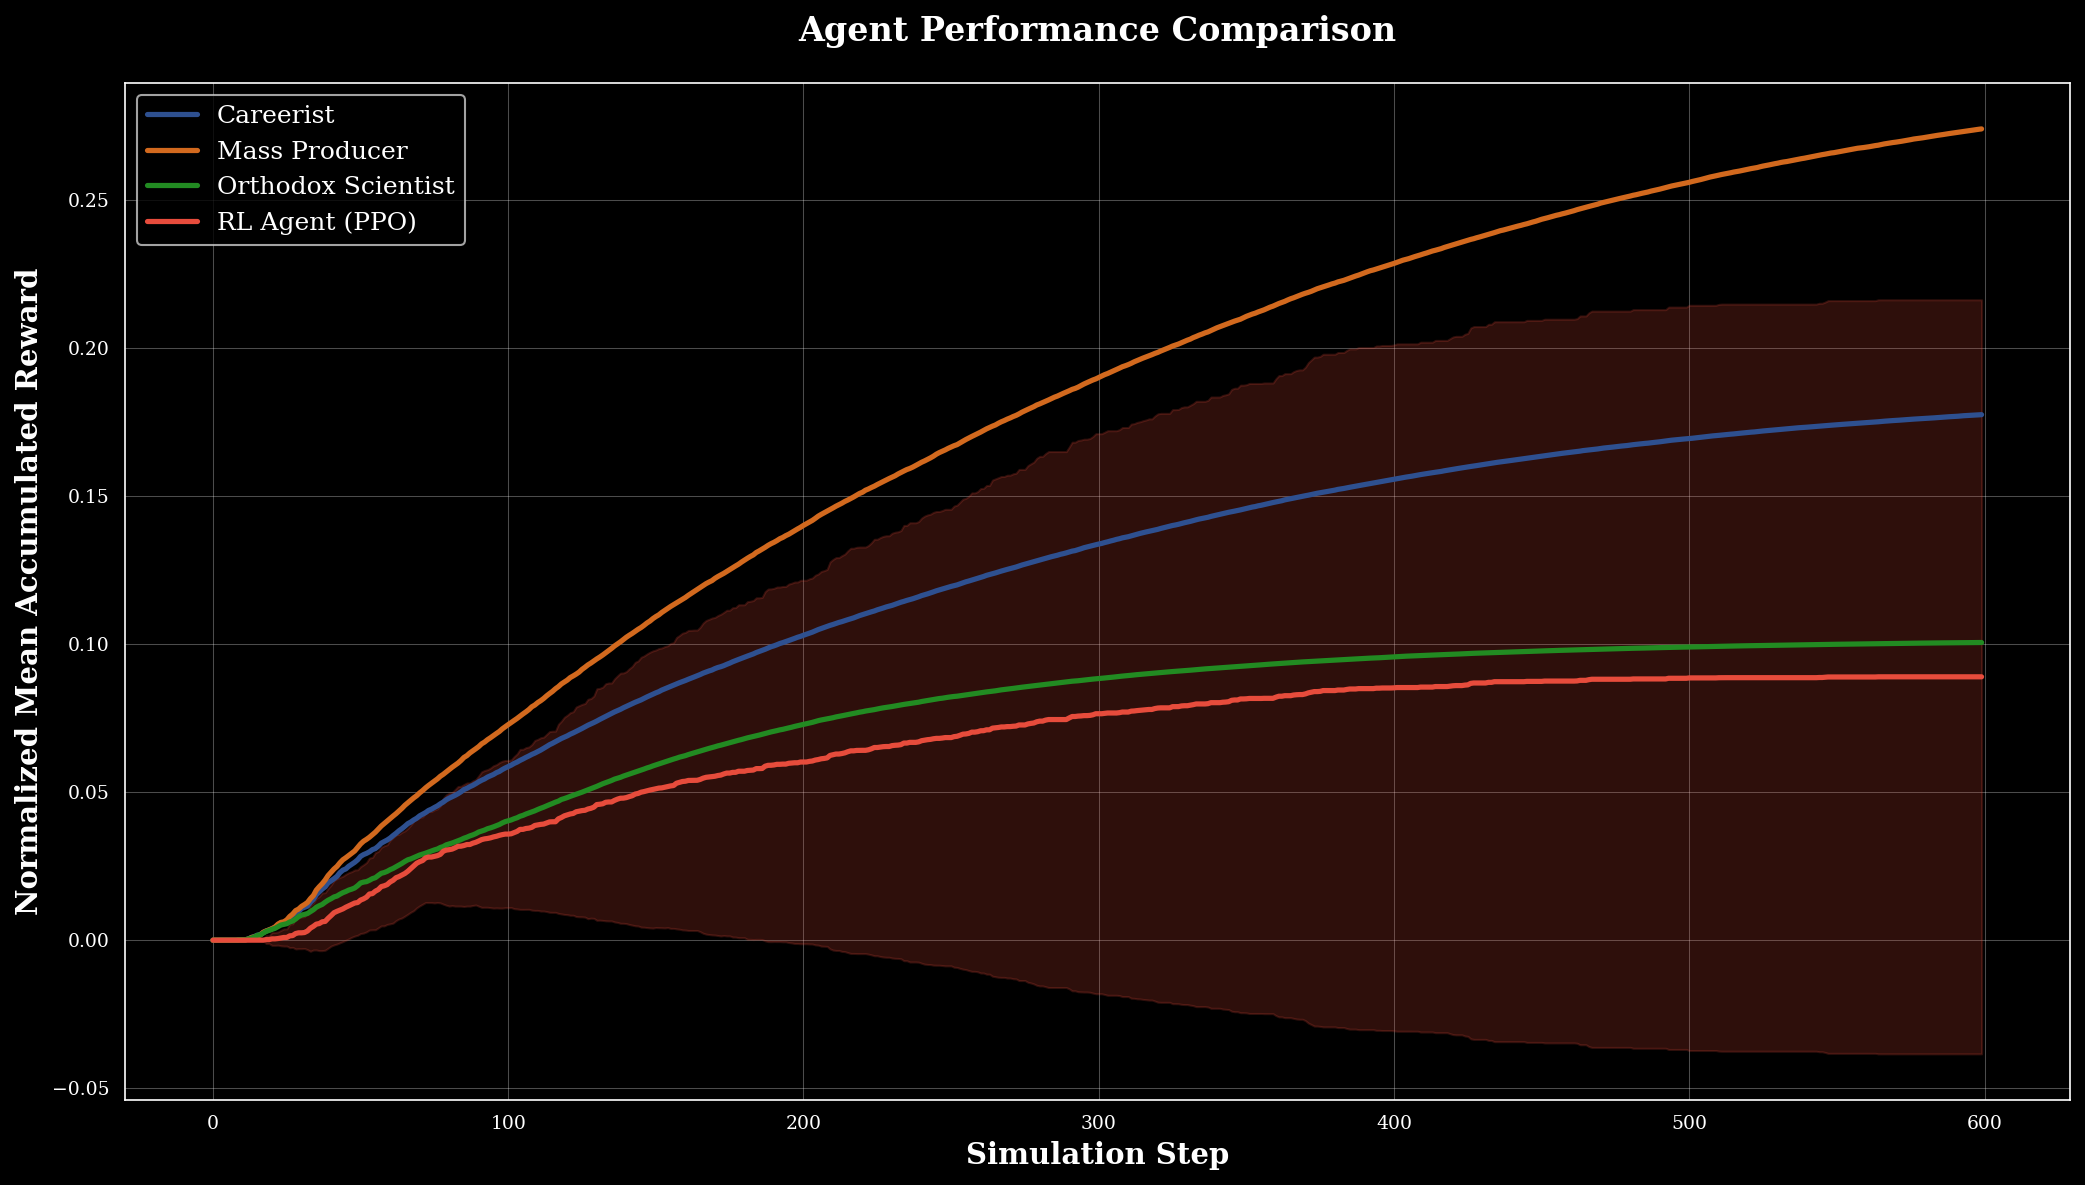

In [10]:
fig, summary_ppo, norm_ppo = plot_archetype_vs_controlled_agent(
    df_traj=ppo_trajectory,
    strategy_name="by_effort",
    algorithm="PPO",
    normalize=True,
    band="std"
)

Global max reward after filtering: 34.424828
careerist: 13355 evaluated units
mass_producer: 13270 evaluated units
orthodox_scientist: 13240 evaluated units
rl_agent: 100 evaluated units

Performance Statistics (with missing_mode='ffill')
Careerist                | Mean: 0.177199 | Std: 0.214981 | N: 13355
Mass Producer            | Mean: 0.272004 | Std: 0.253300 | N: 13270
Orthodox Scientist       | Mean: 0.099026 | Std: 0.109790 | N: 13240
RL Agent (APPO)          | Mean: 0.051641 | Std: 0.078683 | N: 100

Normalization factor: 34.424828


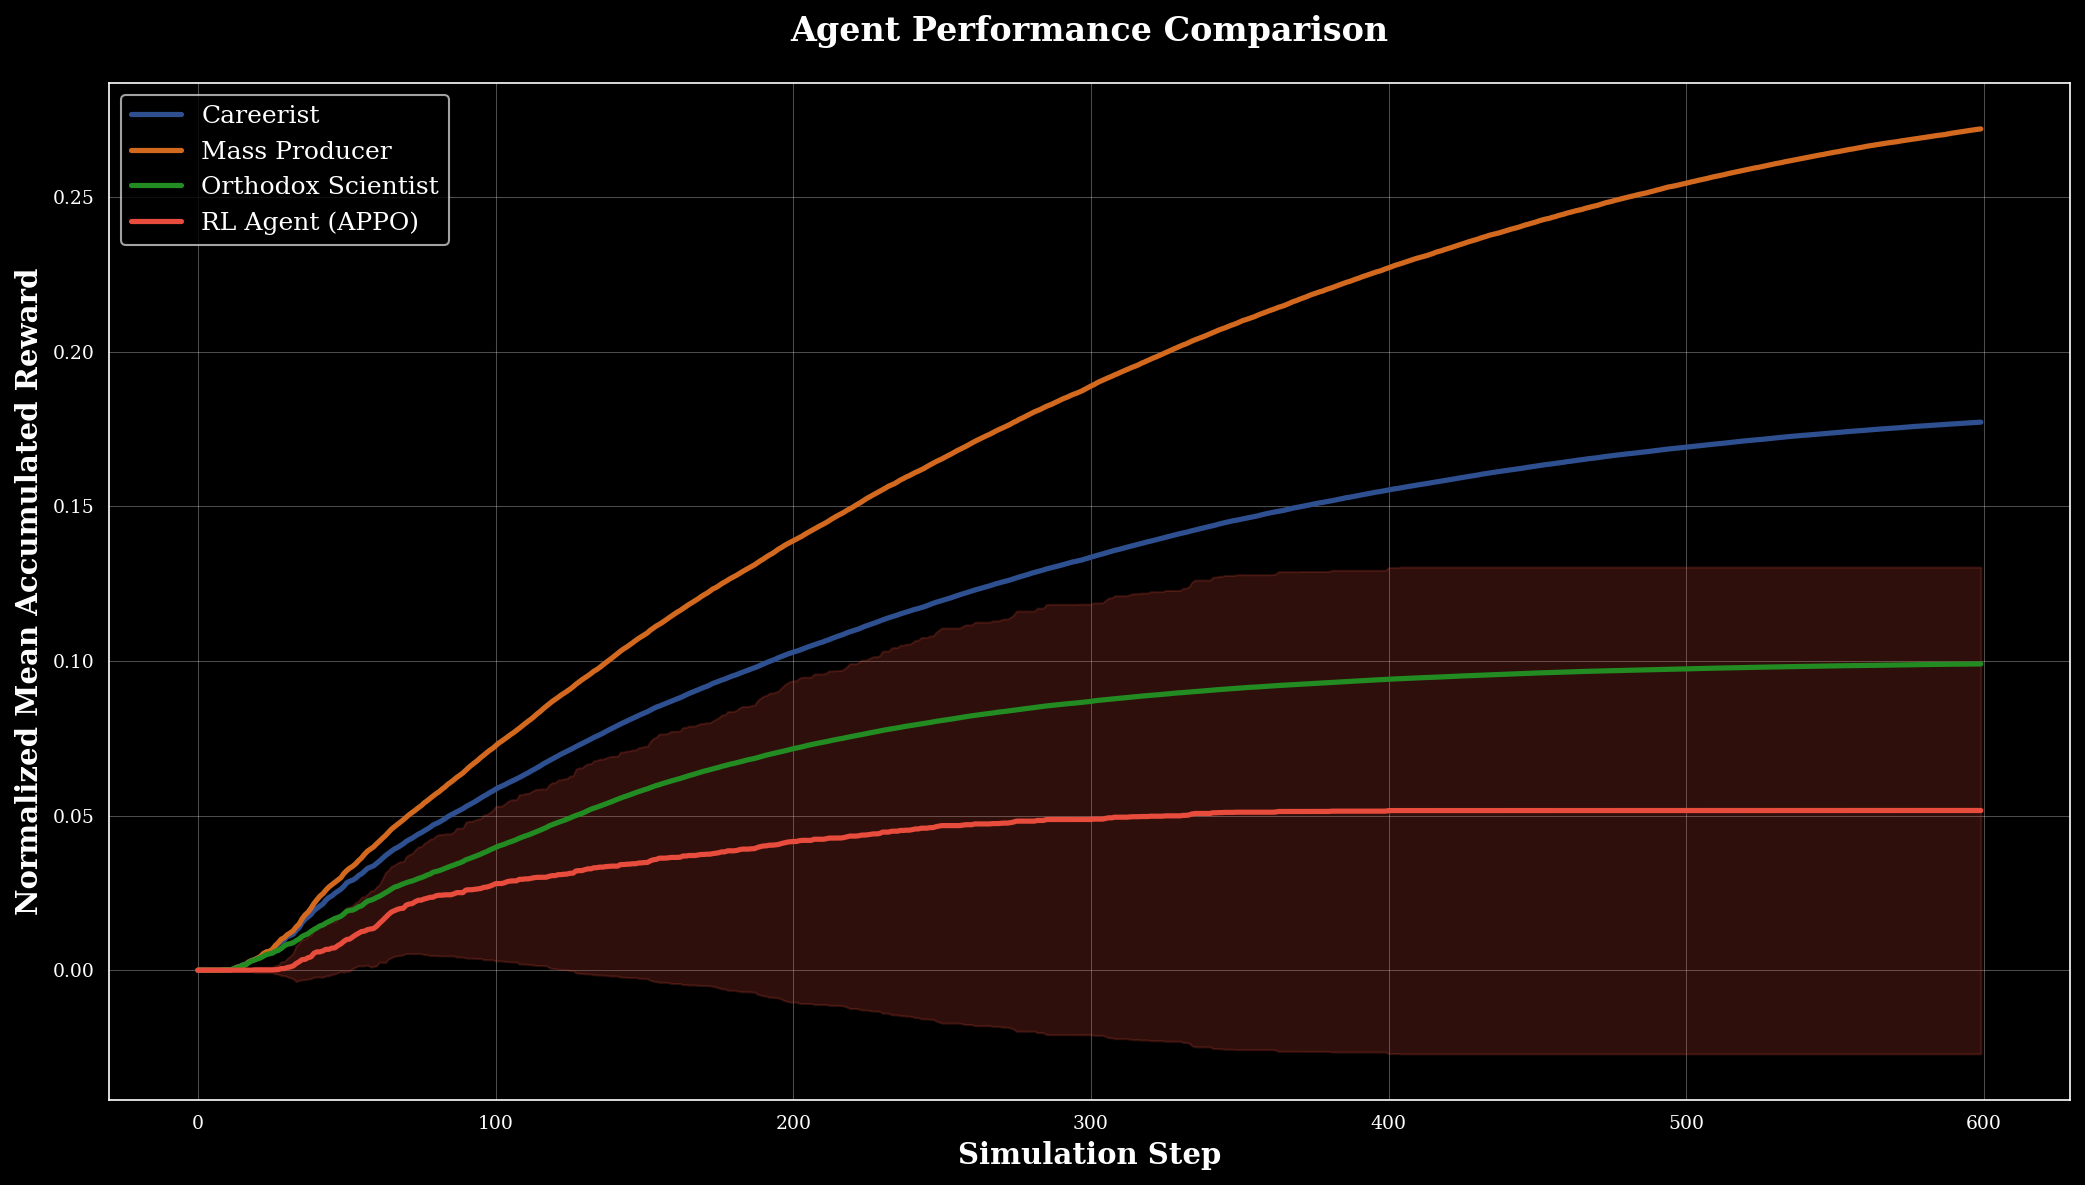

In [13]:
fig, summary_appo, norm_appo = plot_archetype_vs_controlled_agent(
    df_traj=appo_trajectory_df,
    strategy_name="by_effort",
    algorithm="APPO",
    normalize=True,
    band="std"
)

Global max reward after filtering: 45.211197
careerist: 13364 evaluated units
mass_producer: 13259 evaluated units
orthodox_scientist: 13257 evaluated units
random: 100 evaluated units

Performance Statistics (with missing_mode='ffill')
Careerist                | Mean: 0.118384 | Std: 0.150105 | N: 13364
Mass Producer            | Mean: 0.331010 | Std: 0.271279 | N: 13259
Orthodox Scientist       | Mean: 0.065580 | Std: 0.066221 | N: 13257
Random Agent             | Mean: 0.009046 | Std: 0.020874 | N: 100

Normalization factor: 45.211197


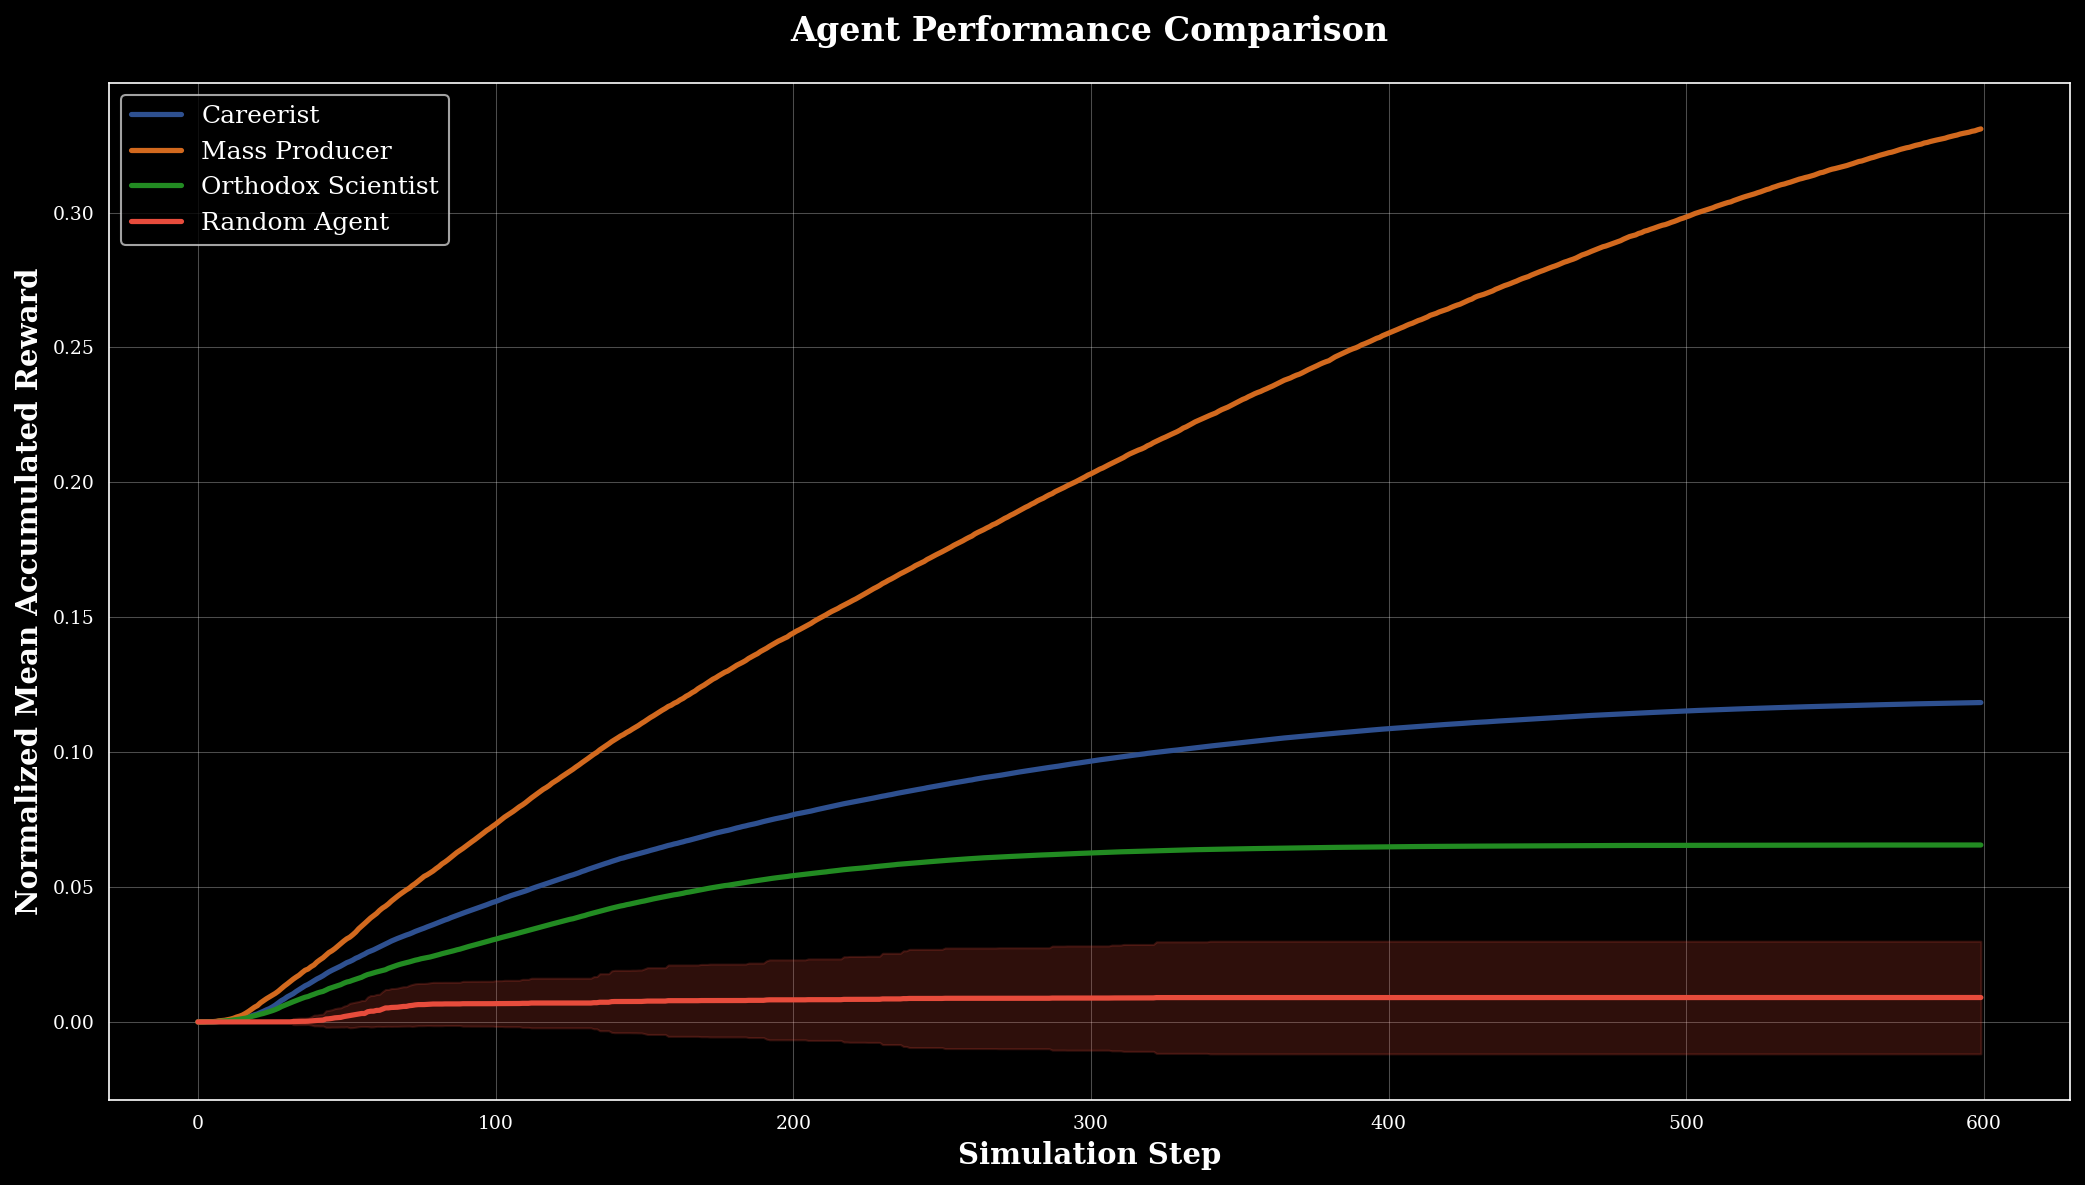

In [15]:
fig, summary_ppo, norm_ppo = plot_archetype_vs_controlled_agent(
    df_traj=random_trajectory_df,
    strategy_name="by_effort",
    algorithm="PPO",
    normalize=True,
    band="std"
)

Shared normalization factor: 43.311928
Saved plot to: plots/archetype_vs_controlled_shared_eval_seeds_exp1.png
Saved plot to: plots/archetype_vs_controlled_shared_eval_seeds_exp1.pdf


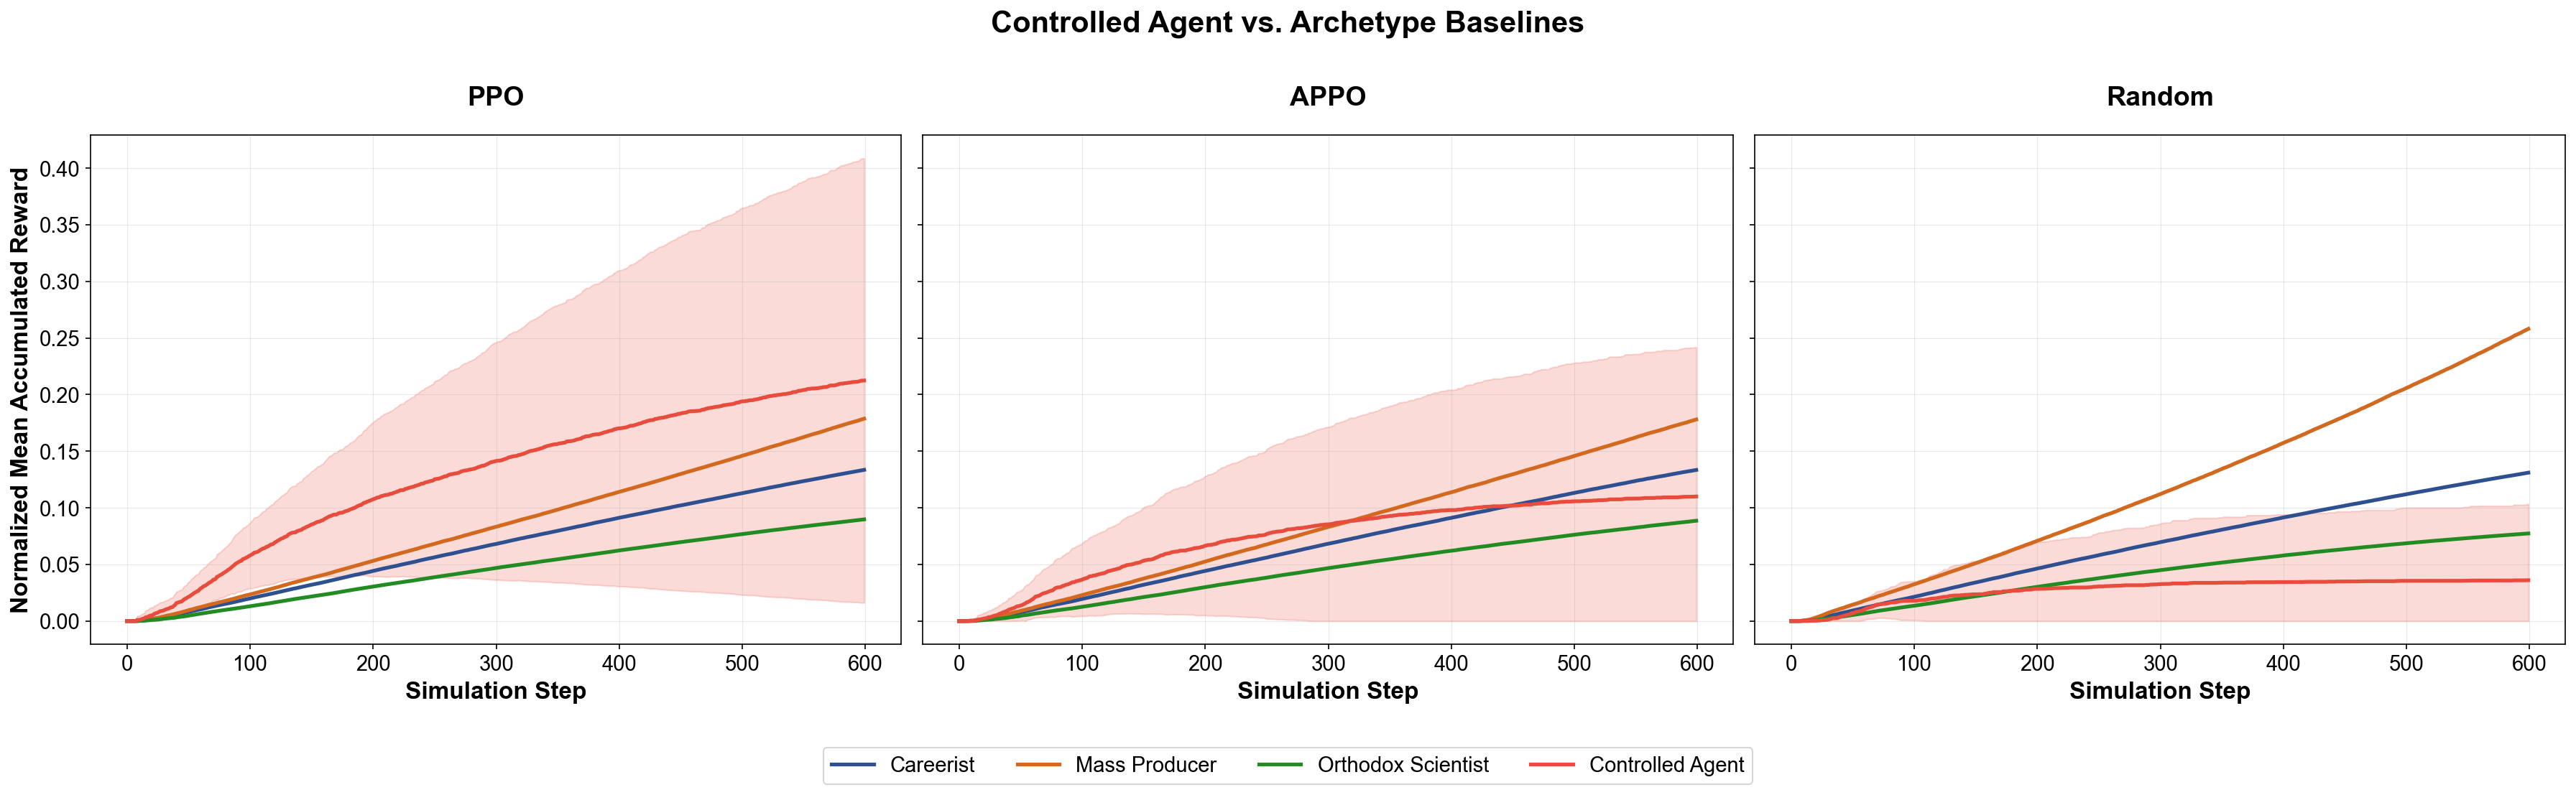

In [6]:
fig, all_summaries, common_norm = plot_archetype_vs_controlled_agent_subplots(
    trajectory_dict={
        "PPO": ppo_trajectory_df,
        "APPO": appo_trajectory_df,
        "Random": random_trajectory_df
    },
    strategy_name="by_effort",
    normalize=True,
    band="std",
    band_for_controlled_only=True,
    clip_band_at_zero=True,
    filename="plots/archetype_vs_controlled_shared_eval_seeds_exp1.png"
)

In [66]:
# fig.savefig(
#     "plots/controlled_agent_vs_archetype_subplots_exp3.png",
#     dpi=600,
#     bbox_inches="tight",
#     facecolor=fig.get_facecolor()
# )

## 2. Detailed Simulation Analysis (Single Seed)
This section performs a deep dive into one specific RL simulation run.


In [ ]:
# Configuration for deep dive
SEED = 501
STRAT = "by_effort" # Change this to "multiply" or "evenly" if desired
RESULT_DIR = "20260427_201740"

try:
    proj_file = f"../test_results/rl_ppo_{STRAT}_s{SEED}_{RESULT_DIR}_s{SEED}/rl_ppo_{STRAT}_s{SEED}_projects.json"
    act_file = f"../test_results/rl_ppo_{STRAT}_s{SEED}_{RESULT_DIR}_s{SEED}/rl_ppo_{STRAT}_s{SEED}_actions.jsonl"
    area_file = f"../test_results/rl_ppo_{STRAT}_s{SEED}_{RESULT_DIR}_s{SEED}/rl_ppo_{STRAT}_s{SEED}_area.pickle"

    with open(proj_file, "r") as f:
        projects = json.load(f)
    with open(act_file, "r") as f:
        actions = [json.loads(line) for line in f]
    print(f"Loaded detailed logs for Seed {SEED} ({STRAT})")

    # Run the standard visualization suite
    plot_histograms(projects, actions)

    # Knowledge Space Visualization
    if os.path.exists(area_file):
        # Versuche Observations zu laden, falls vorhanden
        obs_file = f"../log/rl_ppo_{STRAT}_s{SEED}_observations.jsonl"
        observations = None
        if os.path.exists(obs_file):
            with open(obs_file, "r") as f:
                observations = [json.loads(line) for line in f]
            print(f"Loaded observations for RL Agent trajectory.")
            
        topic_area_per_project(projects, actions, area_file, observations=observations)
        
        # NEU: Animation des Knowledge Space
        print("\nCreating Knowledge Space Animation...")
        ani = animate_knowledge_space(projects, actions, area_file, observations=observations)
        # Um die Animation im Notebook anzuzeigen:
        # display(HTML(ani.to_jshtml()))
        # In einer statischen Umgebung speichern wir sie oder geben einen Hinweis
        # ani.save("knowledge_space_evolution.mp4")
        print("Animation created. Use 'HTML(ani.to_jshtml())' to view it in a Jupyter cell.")
    else:
        print(f"Area file not found at {area_file}")
except FileNotFoundError as e:
    print(f"Could not load detailed logs for Seed {SEED} ({STRAT}): {e}")

# %% [markdown]
# ## 2.1 Knowledge Space Animation
# Führe diese Zelle aus, um die Animation der Publikationen über die Zeit zu sehen.

# %%
if 'ani' in locals():
    from IPython.display import HTML
    display(HTML(ani.to_jshtml()))
else:
    print("Animation object 'ani' not found. Please run the Detailed Simulation Analysis cell first.")

# %%
# ### Archetype Proportions Over Time
# Tracks how the population composition (heuristic types + RL agent) changes during the run.

In [ ]:
if 'actions' in locals():
    visualize_policy_population(actions)


## Performance Comparison Between the RL Agent and Heuristic Archetypes

In [ ]:
# =========================================================
# CONFIG
# =========================================================

variants = {
    "multiply": "conventional",
    "even": "fractional",
    "by_effort": "by effort"
}

archetypes = [
    "careerist",
    "orthodox_scientist",
    "mass_producer",
    "rl_agent"
]

baseline_arch = "rl_agent"
comparison_archetypes = [
    "careerist",
    "orthodox_scientist",
    "mass_producer"
]

time_steps = list(range(600))

# RL agent vs each archetype
pairs = [(baseline_arch, arch) for arch in comparison_archetypes]
pair_colors = {
    ("rl_agent", "careerist"): "#e41a1c",
    ("rl_agent", "orthodox_scientist"): "#377eb8",
    ("rl_agent", "mass_producer"): "#4daf4a"
}

USE_AGE_NORMALIZATION = True
ALPHA = 0.05
FDR_METHOD = "fdr_bh"
N_BOOT = 2000
CI_MODE = "ci"   # "ci" or "se"


# =========================================================
# LOAD DATA
# =========================================================

dfs = {}

for v in variants:
    heuristic_path = f"results/reward_trajectories_{v if v != 'even' else 'evenly'}.parquet"
    rl_path = f"results/rl_trajectories_{v if v != 'even' else 'evenly'}.parquet"

    # Heuristic trajectories
    df_h = pd.read_parquet(heuristic_path)

    # RL trajectories: only keep rl_agent
    df_rl_all = pd.read_parquet(rl_path)
    df_rl_agent = df_rl_all[df_rl_all["archetype"] == "rl_agent"].copy()

    # Merge
    dfs[v] = pd.concat([df_h, df_rl_agent], ignore_index=True)


# =========================================================
# HELPER FUNCTIONS
# =========================================================

def get_variant_global_max(df_variant, reward_col="accumulated_rewards"):
    """
    One shared normalization constant per reward variant across all archetypes.
    This keeps comparisons between rl_agent and archetypes fair within a variant.
    """
    if df_variant.empty:
        return np.nan
    return df_variant[reward_col].max()


def prepare_plot_data_for_variant(df_variant, variant_label):
    """
    Build plotting dataframe for one reward variant across all archetypes.
    Applies one shared normalization constant within the variant.
    """
    plot_df = df_variant.copy()

    if plot_df.empty:
        return pd.DataFrame()

    global_max = get_variant_global_max(plot_df)

    if pd.notna(global_max) and global_max > 0:
        plot_df["accumulated_rewards"] = plot_df["accumulated_rewards"] / global_max

    if USE_AGE_NORMALIZATION:
        if "age" not in plot_df.columns:
            raise KeyError(f"'age' column missing in variant '{variant_label}'.")
        plot_df["accumulated_rewards"] = plot_df["accumulated_rewards"] / (plot_df["age"] + 1)

    return plot_df


def run_rl_vs_archetype_stats(plot_df, variant_name):
    """
    Compare RL agent against each fixed archetype for one reward variant.
    Performs Mann-Whitney U test at each time step, then FDR correction.
    """
    pairwise_results = {}

    print(f"\n{'=' * 80}")
    print(f"Reward variant: {variant_name}")
    print(f"{'=' * 80}")

    for rl_arch, other_arch in pairs:
        raw_p_values = []
        n_valid_tests = 0

        df_rl = plot_df[plot_df["archetype"] == rl_arch]
        df_other = plot_df[plot_df["archetype"] == other_arch]

        for t in time_steps:
            d1 = df_rl.loc[df_rl["step"] == t, "accumulated_rewards"].dropna().values
            d2 = df_other.loc[df_other["step"] == t, "accumulated_rewards"].dropna().values

            # Need at least 2 samples per group
            if len(d1) < 2 or len(d2) < 2:
                raw_p_values.append(1.0)
                continue

            # If both groups are identical constants, no difference
            if (
                np.all(d1 == d1[0]) and
                np.all(d2 == d2[0]) and
                d1[0] == d2[0]
            ):
                raw_p_values.append(1.0)
                continue

            try:
                _, p = stats.mannwhitneyu(d1, d2, alternative="two-sided")
                raw_p_values.append(p)
                n_valid_tests += 1
            except ValueError:
                raw_p_values.append(1.0)

        reject, pvals_corrected, _, _ = multipletests(
            raw_p_values,
            alpha=ALPHA,
            method=FDR_METHOD
        )

        label = f"rl agent vs {other_arch.replace('_', ' ')}"
        pairwise_results[label] = {
            "reject": reject,
            "pvals_corrected": pvals_corrected,
            "raw_p_values": np.array(raw_p_values),
            "pair": (rl_arch, other_arch),
            "color": pair_colors[(rl_arch, other_arch)],
            "n_valid_tests": n_valid_tests
        }

    for label, result in pairwise_results.items():
        proportion_sig = np.mean(result["reject"])
        min_p_corr = np.min(result["pvals_corrected"])
        median_p_corr = np.median(result["pvals_corrected"])

        print(
            f"{label:<38} | "
            f"sig. proportion: {proportion_sig:>6.3f} | "
            f"min p(FDR): {min_p_corr:>8.5f} | "
            f"median p(FDR): {median_p_corr:>8.5f} | "
            f"valid tests: {result['n_valid_tests']:>3d}/{len(time_steps)}"
        )

    return pairwise_results


def add_significance_bars(ax, pairwise_results):
    """
    Add significance markers above the plot.
    """
    y_min, y_max = ax.get_ylim()
    y_range = y_max - y_min

    if y_range == 0:
        y_range = 1e-6

    current_height = y_max + (y_range * 0.02)
    step_height = y_range * 0.05

    for label, result in pairwise_results.items():
        is_sig = result["reject"]
        sig_steps = np.array(time_steps)[is_sig]

        if len(sig_steps) > 0:
            ax.scatter(
                sig_steps,
                [current_height] * len(sig_steps),
                marker="|",
                s=20,
                color=result["color"],
                label=label
            )

        current_height += step_height

    ax.set_ylim(y_min, current_height + step_height)


def prettify_arch_name(name):
    return name.replace("_", " ")


# =========================================================
# PLOTTING
# =========================================================

sns.set_style("whitegrid")

fig, axes = plt.subplots(1, 3, figsize=(21, 7), sharey=False)

if len(variants) == 1:
    axes = [axes]

for idx, v in enumerate(variants):
    ax = axes[idx]
    variant_label = variants[v]

    print(f"\nProcessing reward variant: {variant_label} ...")

    df_variant = dfs[v].copy()
    plot_df = prepare_plot_data_for_variant(df_variant, variant_label)

    # Keep only archetypes of interest
    plot_df = plot_df[plot_df["archetype"].isin(archetypes)].copy()

    if plot_df.empty:
        ax.set_title(f"{variant_label} (no data)")
        ax.text(0.5, 0.5, "No data available", ha="center", va="center", transform=ax.transAxes)
        continue

    # Plot all archetypes for this reward variant
    sns.lineplot(
        data=plot_df,
        x="step",
        y="accumulated_rewards",
        hue="archetype",
        hue_order=archetypes,
        ax=ax,
        errorbar=CI_MODE,
        n_boot=N_BOOT,
        seed=10
    )

    # Statistics: rl_agent vs the 3 archetypes
    pairwise_results = run_rl_vs_archetype_stats(plot_df, variant_label)

    # Significance markers
    add_significance_bars(ax, pairwise_results)

    # Styling
    ax.set_title(f"Reward variant: {variant_label}")
    ax.set_xlabel("Step")
    ax.set_ylabel("Normalized accumulated rewards")

    # Remove local legend
    leg = ax.get_legend()
    if leg:
        leg.remove()


# =========================================================
# GLOBAL LEGEND
# =========================================================

# Build legend manually from first axis
handles, labels = axes[0].get_legend_handles_labels()

# Deduplicate while preserving order
seen = set()
unique_handles = []
unique_labels = []

for h, l in zip(handles, labels):
    if l not in seen:
        seen.add(l)
        unique_handles.append(h)
        unique_labels.append(l)

fig.legend(
    unique_handles,
    unique_labels,
    loc="upper center",
    bbox_to_anchor=(0.5, 1.05),
    ncol=max(1, len(unique_labels)),
    fontsize="large",
    frameon=False
)

plt.tight_layout()
plt.show()